In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import h5py
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, OneHotEncoder

from keras.models import Sequential
from keras.layers import Input, Reshape, Dense, Dropout, SpatialDropout2D, Conv2D, MaxPooling2D, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from ISLP import confusion_table

# 1. Data Sourcing and Preprocessing

We will use neural networks to classify birds from their sound. The original data was taken from this [Birdcall competition data](https://www.kaggle.com/datasets/rohanrao/xeno-canto-bird-recordings-extended-a-m) (which was originally from the crowd-sourced wildlife sound archive [Xeno-Canto](https://xeno-canto.org/)), but we will be using a subsetted and processed version of the data (found [here](https://github.com/mendible/5322/tree/main/Homework%203)) that computed the _spectrograms_ of the sound files (`select_birds.ipynb`) for 12 species of birds and stored them in `bird_spectrograms.hdf5`. A spectrogram is a visual representation of sound frequency over time; you can think of it as an _image_ of a sound. Importantly, this will allow us to classify bird calls using image classification techniques (in particular, convolutional neural networks).

In [3]:
data_file = "data/bird_spectrograms.hdf5"
f = h5py.File(data_file, "r")

In [4]:
species = list(f.keys())
for spec in f.keys():
    print(f"{spec}: {f[spec].shape}")

amecro: (128, 517, 66)
amerob: (128, 517, 172)
bewwre: (128, 517, 144)
bkcchi: (128, 517, 45)
daejun: (128, 517, 125)
houfin: (128, 517, 84)
houspa: (128, 517, 630)
norfli: (128, 517, 37)
rewbla: (128, 517, 187)
sonspa: (128, 517, 263)
spotow: (128, 517, 137)
whcspa: (128, 517, 91)


The output above shows the species code along with the dimensions of the data for that species. For example, "amecro" is the code for the American Crow; 128 (frequency) by 517 (time) is the dimensions of the spectrograms, while 66 is the number of samples we have for the American Crow. The codes and their correspond species are:

- **amecro**: American Crow
- **amerob**: American Robin
- **bewwre**: Berwick's Wren
- **bkcchi**: Black-capped Chickadee
- **daejun**: Dark-eyed Junco
- **houfin**: House Finch
- **houspa**: House Sparrow
- **norfli**: Northern Flicker
- **rewbla**: Red-winged Blackbird
- **sonspa**: Song Sparrow
- **spotow**: Spotted Towhee
- **whcspa**: White-crowned Sparrow


Looking at the number of samples for each species, we see that there is a somewhat large class imbalance. In particular, there are 630 samples for the House Sparrow, but only 37 samples for the Northern Flicker. Since we only care about training a model to distinguish the birds (and not about the relative frequencies of birds in the dataset), we will use undersampling to balance the classes so that the most common class has at most twice as many samples as the least common class.

In [63]:
height, width = 128, 517  # height and width of spectrograms

def get_data(species):
    # number of samples for each class
    num_class_samples = [f[spec].shape[2] for spec in species]
    max_class_samples = 2*np.min(num_class_samples)
    num_class_samples = [min(m,max_class_samples) for m in num_class_samples]

    n = np.sum(num_class_samples)  # total number of samples

    # n; each (flattened) sample is length height*width
    X = np.zeros((n,height*width))
    y = np.zeros(n, dtype="<U6")  # we know that the species codes are all 6 characters

    j = 0
    for i,spec in enumerate(species):
        m = num_class_samples[i]

        # grab first m samples
        species_data = f[spec][:,:,:m]  # 128,517,m

        # equivalent to X[j] = species_data[:,:,j].flatten() for all j
        X[j:j+m] = species_data.transpose(2,0,1).reshape(m,-1)
        y[j:j+m] = spec

        print(f"{spec}: {j},{j+m-1}  ({m})")

        j += m
    
    # the values of X are (approximately) between -80 and 0
    X_scaled = (X+80)/80

    if len(species)==2:
        enc = LabelBinarizer()
        y_encoded = enc.fit_transform(y)
    else:
        enc = OneHotEncoder(sparse_output=False)
        y_encoded = enc.fit_transform(y.reshape(-1,1))

    return X_scaled,y_encoded,enc

In [64]:
# Binary Model Data
Xb, yb, encb = get_data(species=["amecro","rewbla"])

amecro: 0,65  (66)
rewbla: 66,197  (132)


In [65]:
print(encb.classes_)
print(Xb.shape,yb.shape)
print(np.min(Xb),np.max(Xb))

['amecro' 'rewbla']
(198, 66176) (198, 1)
0.0 1.0000000238418578


In [66]:
# sanity check
print(encb.inverse_transform(yb[67]))
print(Xb[67])
print(1+f["rewbla"][:,:,1].flatten()/80)

['rewbla']
[0.17991581 0.3092772  0.34895105 ... 0.         0.         0.        ]
[0.17991581 0.3092772  0.34895105 ... 0.         0.         0.        ]


In [67]:
# Multi-class Model Data
Xm, ym, encm = get_data(species=species)

amecro: 0,65  (66)
amerob: 66,139  (74)
bewwre: 140,213  (74)
bkcchi: 214,258  (45)
daejun: 259,332  (74)
houfin: 333,406  (74)
houspa: 407,480  (74)
norfli: 481,517  (37)
rewbla: 518,591  (74)
sonspa: 592,665  (74)
spotow: 666,739  (74)
whcspa: 740,813  (74)


In [68]:
print(encm.categories_)
print(Xm.shape,ym.shape)
print(np.min(Xm),np.max(Xm))

[array(['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin',
       'houspa', 'norfli', 'rewbla', 'sonspa', 'spotow', 'whcspa'],
      dtype='<U6')]
(814, 66176) (814, 12)
0.0 1.0000000238418578


In [76]:
# sanity check
print(encm.inverse_transform(ym[[0,66,140,214,259,333,407,481,518,592,666,740]])[:,0])
print(Xm[340])
print(1+f["houfin"][:,:,7].flatten()/80)

['amecro' 'amerob' 'bewwre' 'bkcchi' 'daejun' 'houfin' 'houspa' 'norfli'
 'rewbla' 'sonspa' 'spotow' 'whcspa']
[0.13432064 0.11005001 0.07989178 ... 0.         0.         0.15212765]
[0.13432064 0.11005001 0.07989178 ... 0.         0.         0.15212765]


# 2. Data Modeling

## 2.1 Binary Model: amecro vs. rewbla

First, we will build a model to distinguish between American Crows (amecro) and Red-winged Blackbirds (rewbla). We will try a "lightweight" CNN without much regularization as well as a more complex CNN with more regularization.

In [87]:
# Split into training and test sets (70-30 split)
Xb_train,Xb_test,yb_train,yb_test = train_test_split(
    Xb,
    yb,
    train_size=0.7,
    random_state=5322
)

print(Xb_train.shape, yb_train.shape)
print(Xb_test.shape, yb_test.shape)

(138, 66176) (138, 1)
(60, 66176) (60, 1)


In [289]:
CNNb_light = Sequential([
    # input + reshape
    Input(shape=(height*width,)),
    Reshape(target_shape=(height,width,1)),

    # convolution + pooling block
    Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.2),

    # flatten + fully connected layers
    Flatten(),
    Dense(units=64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(units=1, activation="sigmoid")
])

CNNb_light.compile(
    optimizer=Adam(learning_rate=3e-4),  # A Recipe for Training Neural Networks
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [290]:
histb_light = CNNb_light.fit(
    Xb_train, yb_train,
    epochs=30,
    batch_size=4,  # remember, there are only 138 training samples
    validation_data=(Xb_test, yb_test)
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.5280 - loss: 0.8638 - val_accuracy: 0.3667 - val_loss: 0.7972
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.6781 - loss: 0.5965 - val_accuracy: 0.6000 - val_loss: 0.7026
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6374 - loss: 0.5888 - val_accuracy: 0.6500 - val_loss: 0.6487
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.7458 - loss: 0.5424 - val_accuracy: 0.7167 - val_loss: 0.5584
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6265 - loss: 0.6289 - val_accuracy: 0.7333 - val_loss: 0.5487
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7829 - loss: 0.4817 - val_accuracy: 0.7667 - val_loss: 0.5326
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7337 - loss: 0.5756 - val_accuracy: 0.7167 - val_loss: 0.5347
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7935 - loss: 0.4188 - val_accuracy: 0.7333 - v

In [ ]:
CNNb_heavy = Sequential([
    # input + reshape
    Input(shape=(height*width,)),
    Reshape(target_shape=(height,width,1)),

    # first convolution + pooling block
    Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # second convolution + pooling block
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.3),

    # flatten + fully connected layers
    Flatten(),
    Dense(units=64, activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dense(units=1, activation="sigmoid")
])

CNNb_heavy.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [283]:
histb_heavy = CNNb_heavy.fit(
    Xb_train, yb_train,
    epochs=30,
    batch_size=4,
    validation_data=(Xb_test, yb_test)
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.5533 - loss: 1.2213 - val_accuracy: 0.3333 - val_loss: 0.9176
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5431 - loss: 0.8940 - val_accuracy: 0.3500 - val_loss: 0.9034
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.7744 - loss: 0.6808 - val_accuracy: 0.3667 - val_loss: 0.9001
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.6847 - loss: 0.8041 - val_accuracy: 0.8167 - val_loss: 0.7924
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.7306 - loss: 0.6764 - val_accuracy: 0.7500 - val_loss: 0.7465
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8110 - loss: 0.5945 - val_accuracy: 0.7500 - val_loss: 0.7129
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8272 - loss: 0.5947 - val_accuracy: 0.7667 - val_loss: 0.6914
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8392 - loss: 0.5713 - val_accuracy: 0.8667 - v

Test Accuracy: 83.33%


In [315]:
def plot_history(hist):
    history = hist.history

    plt.figure(figsize=(14, 6))
    epochs = range(1, len(history["loss"])+1)

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs,history["loss"],"o-",color="b",linewidth=2,markersize=5,label="Training Loss")
    plt.plot(epochs,history["val_loss"],"o-",color="orange",linewidth=2,markersize=5,label="Test Loss")
    plt.title("Loss",fontsize=16)
    plt.xlabel("Epochs",fontsize=14)
    plt.ylabel("Loss",fontsize=14)
    plt.grid(visible=True,linestyle="--",alpha=0.5)
    plt.legend(fontsize=12,frameon=True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs,history["accuracy"],"o-",color="b",linewidth=2,markersize=5,label="Training Accuracy")
    plt.plot(epochs,history["val_accuracy"],"o-",color="orange",linewidth=2,markersize=5,label="Test Accuracy")
    plt.title("Accuracy",fontsize=16)
    plt.xlabel("Epochs",fontsize=14)
    plt.ylabel("Accuracy",fontsize=14)
    plt.ylim(0, 1.05)
    plt.grid(visible=True,linestyle="--",alpha=0.5)
    plt.legend(fontsize=12,frameon=True)

    plt.tight_layout()
    plt.show()

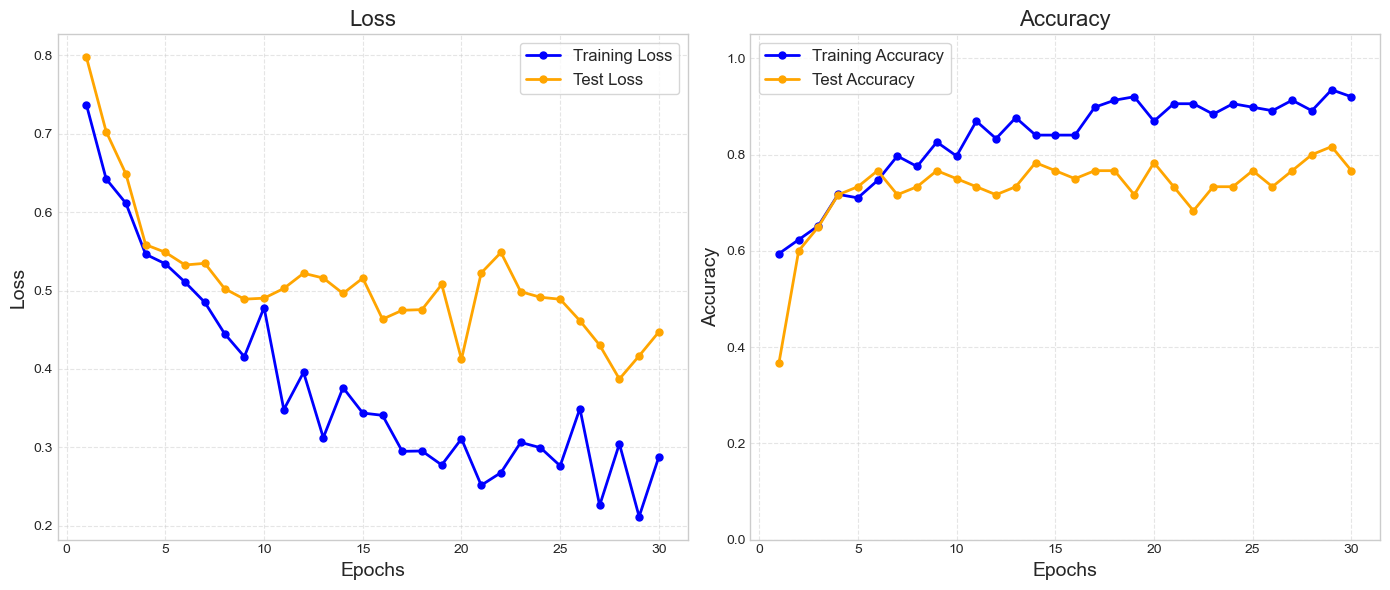

Test Accuracy: 76.67%


In [316]:
plot_history(histb_light)
print("Test Accuracy: {:.2f}%".format(CNNb_light.evaluate(Xb_test, yb_test, verbose=0)[1]*100))

In [336]:
yb_pred = CNNb_light.predict(Xb_test, verbose=0)
yb_pred = np.where(yb_pred>0.5, 1, 0)
yb_pred = encb.inverse_transform(yb_pred)
yb_truth = encb.inverse_transform(yb_test)
confusion_table(yb_pred,yb_truth)

Truth,amecro,rewbla
Predicted,,
amecro,11,5
rewbla,9,35


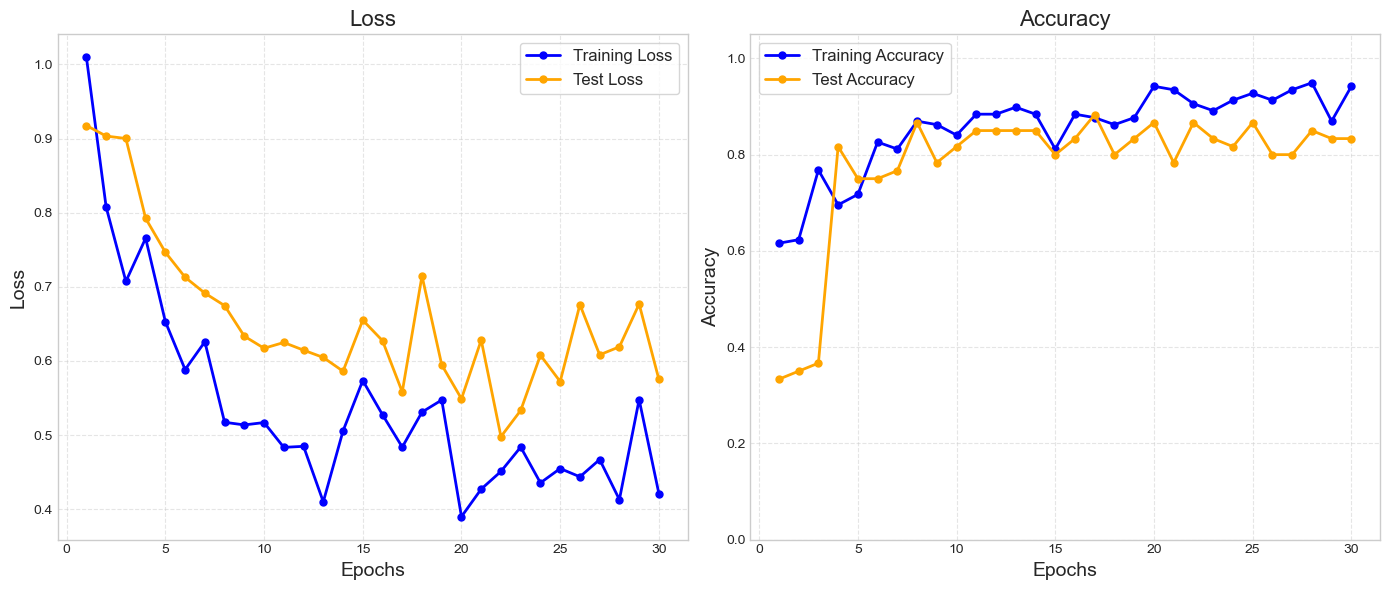

Test Accuracy: 83.33%


In [317]:
plot_history(histb_heavy)
print("Test Accuracy: {:.2f}%".format(CNNb_heavy.evaluate(Xb_test, yb_test, verbose=0)[1]*100))

In [337]:
yb_pred = CNNb_heavy.predict(Xb_test, verbose=0)
yb_pred = np.where(yb_pred>0.5, 1, 0)
yb_pred = encb.inverse_transform(yb_pred)
yb_truth = encb.inverse_transform(yb_test)
confusion_table(yb_pred,yb_truth)

Truth,amecro,rewbla
Predicted,,
amecro,14,4
rewbla,6,36


## 2.2 Multi-class Model

Now, we will build a model to distinguish between all 12 species. Again, we will try a "lightweight" CNN without much regularization and a more complex CNN with more regularization.

In [297]:
# Split into training and test sets (70-30 split)
Xm_train,Xm_test,ym_train,ym_test = train_test_split(
    Xm,
    ym,
    train_size=0.7,
    random_state=5322
)

print(Xm_train.shape, ym_train.shape)
print(Xm_test.shape, ym_test.shape)

(569, 66176) (569, 12)
(245, 66176) (245, 12)


In [ ]:
CNNm_light = Sequential([
    # input + reshape
    Input(shape=(height*width,)),
    Reshape(target_shape=(height,width,1)),

    # first convolution + pooling block
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # second convolution + pooling block
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.25),

    # flatten + fully connected layers
    Flatten(),
    Dense(units=64, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),
    Dense(units=12, activation="softmax")
])

CNNm_light.compile(
    optimizer=Adam(learning_rate=3e-4),  # A Recipe for Training Neural Networks
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [313]:
histm_light = CNNm_light.fit(
    Xm_train, ym_train,
    epochs=50,
    batch_size=16,  # training set has 569 samples
    validation_data=(Xm_test, ym_test)
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 400ms/step - accuracy: 0.0907 - loss: 3.3392 - val_accuracy: 0.0898 - val_loss: 2.5870
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 561ms/step - accuracy: 0.1819 - loss: 2.4867 - val_accuracy: 0.0898 - val_loss: 2.6397
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 372ms/step - accuracy: 0.2291 - loss: 2.2992 - val_accuracy: 0.0898 - val_loss: 2.5780
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 351ms/step - accuracy: 0.3589 - loss: 1.9386 - val_accuracy: 0.1102 - val_loss: 2.5384
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 370ms/step - accuracy: 0.4604 - loss: 1.6492 - val_accuracy: 0.0939 - val_loss: 2.5140
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 363ms/step - accuracy: 0.6045 - loss: 1.3569 - val_accuracy: 0.1265 - val_loss: 2.5609
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 368ms/step - accuracy: 0.6299 - loss: 1.2107 - val_accuracy: 0.0980 - val_loss: 2.5917
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 366ms/step - accuracy: 0.8119 - loss: 0.7901 - val_accu

In [319]:
CNNm_heavy = Sequential([
    # input + reshape
    Input(shape=(height*width,)),
    Reshape(target_shape=(height,width,1)),

    # first convolution + pooling block
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # second convolution + pooling block
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # third convolution + pooling block
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    SpatialDropout2D(0.25),

    # flatten + fully connected layers
    Flatten(),
    Dense(units=256, activation="relu",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(units=12, activation="softmax")
])

CNNm_heavy.compile(
    optimizer=Adam(learning_rate=3e-4),  # A Recipe for Training Neural Networks
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [320]:
histm_heavy = CNNm_heavy.fit(
    Xm_train, ym_train,
    epochs=50,
    batch_size=16,  # training set has 569 samples
    validation_data=(Xm_test, ym_test)
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 424ms/step - accuracy: 0.1269 - loss: 3.9305 - val_accuracy: 0.0816 - val_loss: 10.2412
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 547ms/step - accuracy: 0.3442 - loss: 2.8279 - val_accuracy: 0.0939 - val_loss: 17.9322
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 534ms/step - accuracy: 0.5997 - loss: 2.0729 - val_accuracy: 0.0939 - val_loss: 19.3385
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7267 - loss: 1.7540 - val_accuracy: 0.0816 - val_loss: 24.0121
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9042 - loss: 1.2242 - val_accuracy: 0.0408 - val_loss: 30.1569
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 616ms/step - accuracy: 0.9568 - loss: 1.0679 - val_accuracy: 0.0408 - val_loss: 32.8251
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9439 - loss: 1.1309 - val_accuracy: 0.0408 - val_loss: 37.8754
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9781 - loss: 0.9961 - val_accuracy:

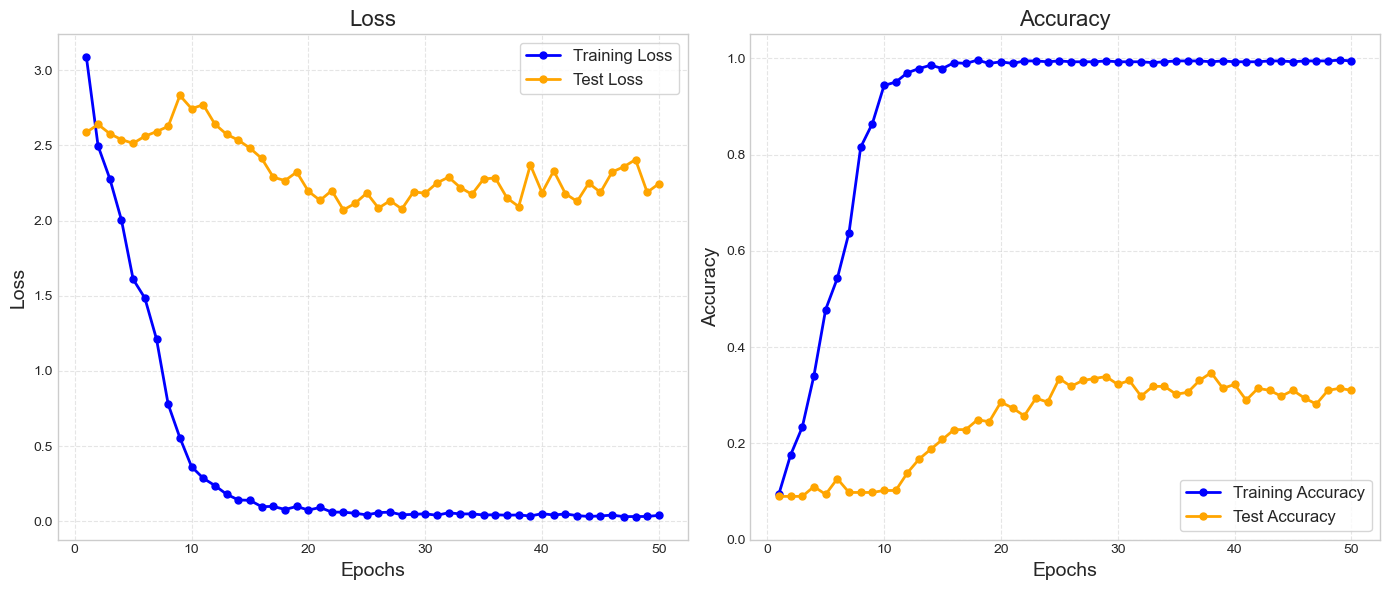

In [338]:
plot_history(histm_light)

In [368]:
ym_pred = encm.inverse_transform(
    # choose index with largest probability, one-hot encode it, and then invert
    OneHotEncoder(sparse_output=False).fit_transform(np.argmax(CNNm_light.predict(Xm_test, verbose=0), axis=1).reshape(-1,1))
)[:,0]
ym_truth = encm.inverse_transform(ym_test)[:,0]
confusion_table(ym_pred,ym_truth)

Truth,amecro,amerob,bewwre,bkcchi,daejun,houfin,houspa,norfli,rewbla,sonspa,spotow,whcspa
Predicted,,,,,,,,,,,,
amecro,19,1,2,1,2,4,6,2,3,0,3,5
amerob,1,9,3,2,1,3,0,2,6,2,0,2
bewwre,1,2,7,0,2,0,1,0,0,6,3,1
bkcchi,0,0,0,2,0,1,2,0,0,0,2,1
daejun,0,0,2,1,6,1,0,1,1,2,1,3
houfin,0,0,2,1,0,5,3,0,0,1,0,1
houspa,0,0,0,1,1,0,8,0,1,0,0,2
norfli,0,1,0,1,0,2,1,0,0,0,0,1
rewbla,0,4,4,2,1,3,4,4,8,8,2,4


<Axes: xlabel='Truth', ylabel='Predicted'>

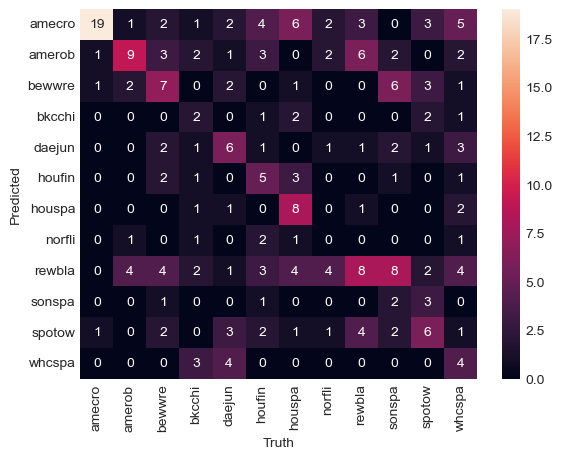

In [369]:
sns.heatmap(confusion_table(ym_pred,ym_truth), annot=True)

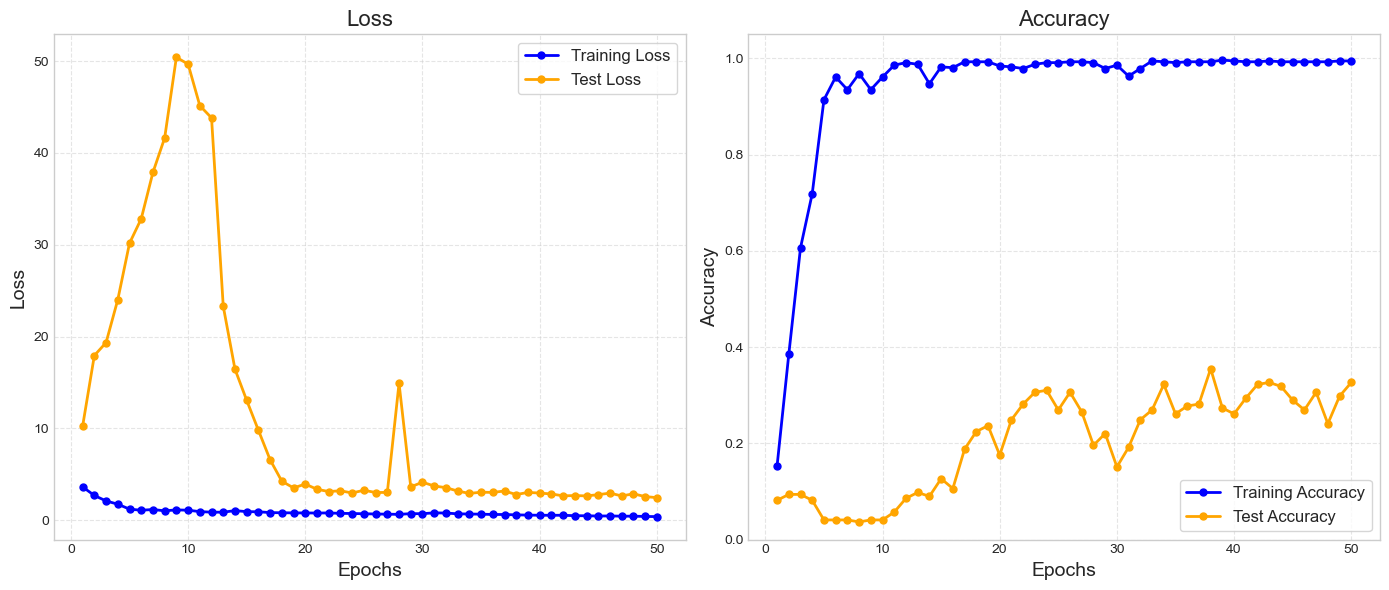

In [322]:
plot_history(histm_heavy)

In [361]:
ym_pred = encm.inverse_transform(
    # choose index with largest probability, one-hot encode it, and then invert
    OneHotEncoder(sparse_output=False).fit_transform(np.argmax(CNNm_heavy.predict(Xm_test, verbose=0), axis=1).reshape(-1,1))
)[:,0]
ym_truth = encm.inverse_transform(ym_test)[:,0]
confusion_table(ym_pred,ym_truth)

Truth,amecro,amerob,bewwre,bkcchi,daejun,houfin,houspa,norfli,rewbla,sonspa,spotow,whcspa
Predicted,,,,,,,,,,,,
amecro,10,0,1,0,0,0,0,0,0,0,0,1
amerob,0,11,1,1,2,3,1,2,6,1,1,1
bewwre,0,0,0,0,0,0,0,0,0,1,0,0
bkcchi,1,0,0,2,0,0,1,0,0,0,1,0
daejun,2,2,4,1,9,0,3,0,2,4,4,5
houfin,0,0,4,0,0,6,1,1,0,0,1,2
houspa,2,0,0,0,2,4,11,1,1,0,1,2
norfli,1,0,0,0,0,1,0,1,0,0,0,0
rewbla,2,4,4,2,0,4,7,4,10,4,4,2


<Axes: xlabel='Truth', ylabel='Predicted'>

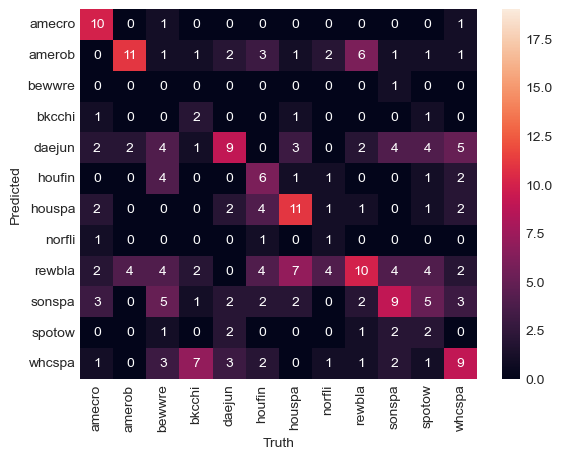

In [ ]:
# vmax = 19 so that color is comparable with previous heatmap
sns.heatmap(confusion_table(ym_pred,ym_truth), annot=True, vmax=19)

# 3. External Test Data

In [371]:
test_files = [f"data/external_test_data/test{i}.mp3" for i in range(1,4)]
test_files

['data/external_test_data/test1.mp3',
 'data/external_test_data/test2.mp3',
 'data/external_test_data/test3.mp3']

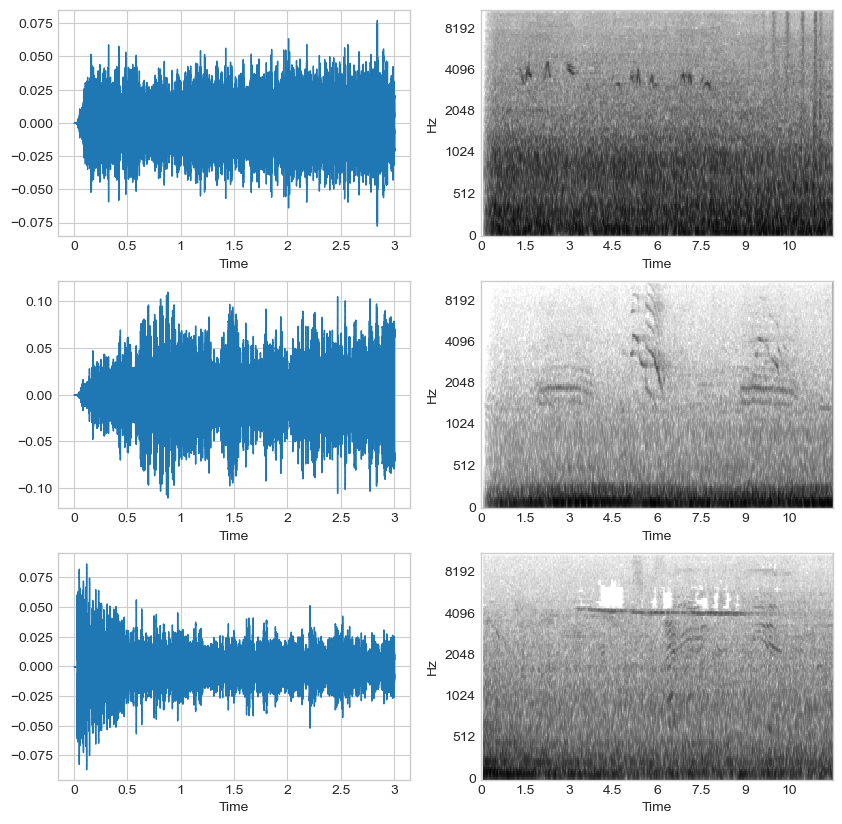

In [ ]:
fig, ax = plt.subplots(nrows=3,ncols=2,figsize=(10,10))
spectrograms = []
for i,test_file in enumerate(test_files):
    y, sr = librosa.load(test_file, duration=3)
    librosa.display.waveshow(y, sr=sr, ax=ax[i][0])

    spec = librosa.feature.melspectrogram(y=y, sr=sr, hop_length=128, win_length=512)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    librosa.display.specshow(spec_db, x_axis='time', y_axis='mel', sr=sr, cmap='gray_r',ax=ax[i][1])
    spectrograms.append(spec_db.flatten())


In [444]:
X_extest = np.vstack(spectrograms)
X_extest.shape

(3, 66176)

In [445]:
np.array(species,dtype="<U6")[np.argmax(CNNm_heavy.predict(X_extest, verbose=0), axis=1)]

array(['whcspa', 'whcspa', 'whcspa'], dtype='<U6')

The (heavyweight) model thinks that all three external test audio files are recordings of a White-crowned Sparrow.